In [ ]:
# **Dünya GSYİH (GDP) Veri Seti - Keşifçi Veri Analizi (EDA)**


In [8]:
# Temel veri işleme kütüphaneleri
import pandas as pd
import numpy as np

# Görselleştirme kütüphaneleri
import matplotlib.pyplot as plt
import seaborn as sns

# Grafiklerin düzgün görünmesi için stil ayarı
sns.set_theme(style="whitegrid")

In [10]:
df = pd.read_csv('World GDP Dataset (1).csv')

df.rename(columns={'GDP, current prices (Billions of U.S. dollars)': 'Country'}, inplace=True)

print('World GDP Verisi')
print('='*50)
print(f'Boyut : {df.shape[0]} satır, {df.shape[1]} sütun')

World GDP Verisi
Boyut : 230 satır, 45 sütun


In [11]:
# İlk 5 satırı görüntüle
df.head()

,Country,1980,1981,1982,1983,1984,1985,1986,1987,1988,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Afghanistan,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,20.616,20.057,18.020,18.883,18.401,18.876,20.136,0.000,0.000,0.000
1,Albania,1.946,2.229,2.296,2.319,2.290,2.339,2.587,2.566,2.530,...,13.246,11.389,11.862,13.053,15.157,15.399,15.161,18.310,18.256,18.842
2,Algeria,42.346,44.372,44.780,47.529,51.513,61.132,61.535,63.300,51.664,...,213.810,165.979,160.034,170.207,175.372,171.680,144.922,162.711,187.155,190.254
3,Andorra,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,3.267,2.789,2.895,2.993,3.217,3.155,2.885,3.330,3.302,3.360
4,Angola,6.639,6.214,6.214,6.476,6.864,8.457,7.918,9.050,9.818,...,145.712,116.194,101.124,122.022,101.353,84.516,58.125,75.179,124.794,135.558


In [ ]:
# Son 5 satır
df.tail()

,Country,1980,1981,1982,1983,1984,1985,1986,1987,1988,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
225,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
226,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
227,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
228,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
229,"©IMF, 2022",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Rastgele 5 satır
df.sample(5)

,Country,1980,1981,1982,1983,1984,1985,1986,1987,1988,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
1,Albania,1.946,2.229,2.296,2.319,2.290,2.339,2.587,2.566,2.530,...,13.246,11.389,11.862,13.053,15.157,15.399,15.161,18.310,18.256,18.842
185,United Kingdom,603.601,587.273,558.348,532.115,504.226,536.592,654.684,813.147,990.234,...,3088.773,2957.227,2732.956,2701.268,2904.513,2880.357,2758.870,3187.626,3198.470,3479.468
71,Guyana,0.842,0.808,0.692,0.703,0.654,0.697,0.789,0.728,0.828,...,4.128,4.280,4.483,4.748,4.788,5.174,5.471,7.717,14.839,16.804
142,Romania,46.053,55.319,55.375,48.401,39.111,48.286,52.290,58.477,60.538,...,199.961,177.731,188.130,211.696,241.456,249.880,249.512,284.086,299.885,311.546
65,Ghana,37.350,60.694,70.406,47.317,17.113,15.255,14.072,11.777,12.523,...,54.285,49.437,56.144,60.385,67.259,68.353,70.008,79.157,75.996,70.086


In [ ]:
## 2. Veri Tipleri ve Temel İstatistikler

# Verinin genel yapı ve tip özeti
df.info()

print('\nSayısal Değişkenlerin Temel İstatistikleri (Seçili Yıllar):')
print('='*60)
# kritik yılları transpoze (.T) ederek inceleme
df[['1980', '2000', '2010', '2023']].describe().T

In [ ]:
## 3. Eksik Veri Analizi ve Temizleme Stratejileri
eksik = df.isnull().sum()
eksik_orani = (eksik / len(df) * 100).round(2)

eksik_df = pd.DataFrame({
    'Eksik Değer Sayısı': eksik,
    'Eksik Oranı (%)': eksik_orani
})
print(eksik_df[eksik_df['Eksik Değer Sayısı'] > 0])

         Eksik Değer Sayısı  Eksik Oranı (%)
Country                  33            14.35
1980                     34            14.78
1981                     34            14.78
1982                     34            14.78
1983                     34            14.78
1984                     34            14.78
1985                     34            14.78
1986                     34            14.78
1987                     34            14.78
1988                     34            14.78
1989                     34            14.78
1990                     34            14.78
1991                     34            14.78
1992                     34            14.78
1993                     34            14.78
1994                     34            14.78
1995                     34            14.78
1996                     34            14.78
1997                     34            14.78
1998                     34            14.78
1999                     34            14.78
2000      

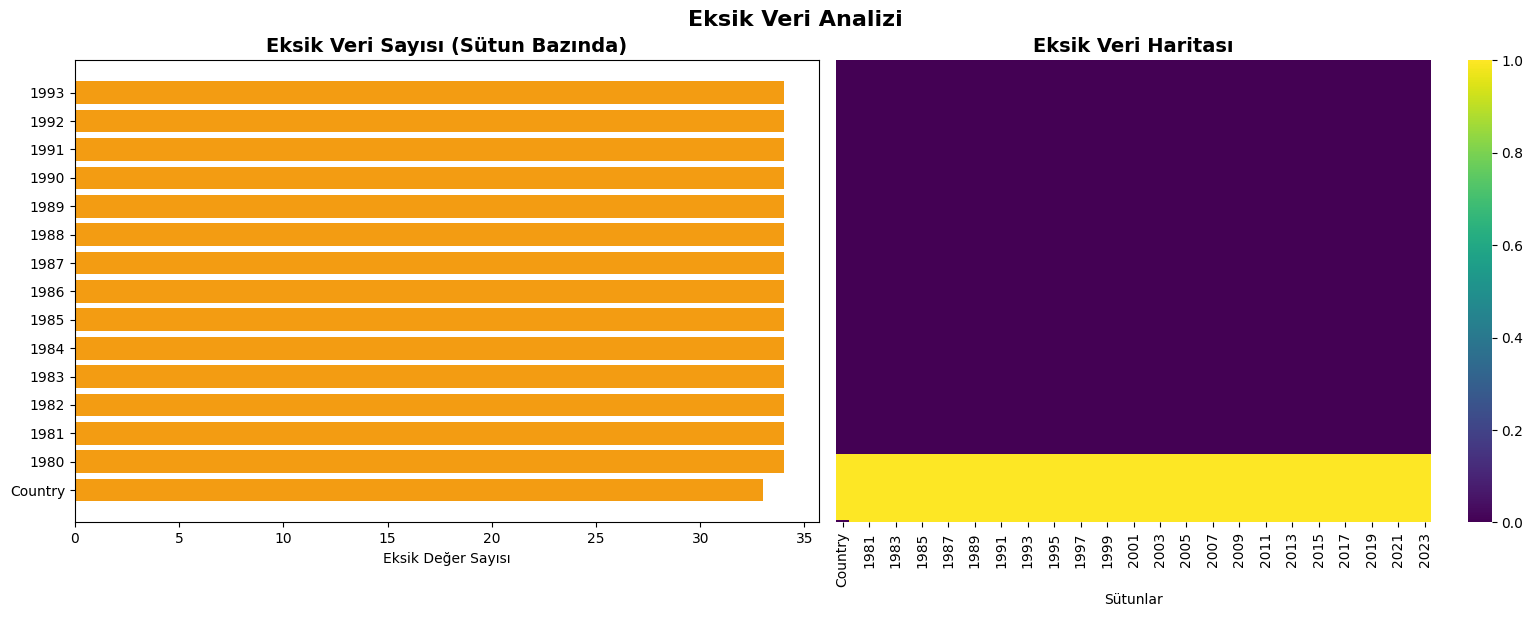

In [ ]:
#Barh + Heatmap eksik veri görselleştirmesi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

eksik_olan = df.isnull().sum()
eksik_olan = eksik_olan[eksik_olan > 0].sort_values(ascending=True)

# Renklendirme
colors = ['#e74c3c' if x > 30 else '#f39c12' if x > 10 else '#3498db' for x in (eksik_olan / len(df) * 100)]

# Sol Panel: Yatay Bar Grafiği
axes[0].barh(eksik_olan.index[:15], eksik_olan.values[:15], color=colors[:15]) # İlk 15 kolonu sığdırıyoruz
axes[0].set_title('Eksik Veri Sayısı (Sütun Bazında)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Eksik Değer Sayısı')

# Sağ Panel: Isı Haritası
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis', ax=axes[1])
axes[1].set_title('Eksik Veri Haritası', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sütunlar')

plt.tight_layout()
plt.suptitle('Eksik Veri Analizi', fontsize=16, fontweight='bold', y=1.02)
plt.show()

In [ ]:
#  boş olan Excel  satırları temizleme
df_temiz = df.copy()
df_temiz.dropna(subset=['Country'], inplace=True)

# Sayısal yıllardaki eksik verileri de sütun medyanı ile doldurma
yillar = [str(yil) for yil in range(1980, 2024)]
for col in yillar:
    df_temiz[col] = pd.to_numeric(df_temiz[col], errors='coerce')
    df_temiz[col] = df_temiz[col].fillna(df_temiz[col].median())

print("Temizlik sonrası toplam eksik değer sayısı:", df_temiz.isnull().sum().sum())

In [ ]:
#  boş olan Excel  satırları temizleme
df_temiz = df.copy()
df_temiz.dropna(subset=['Country'], inplace=True)

# Sayısal yıllardaki eksik verileri de sütun medyanı ile doldurma
yillar = [str(yil) for yil in range(1980, 2024)]
for col in yillar:
    df_temiz[col] = pd.to_numeric(df_temiz[col], errors='coerce')
    df_temiz[col] = df_temiz[col].fillna(df_temiz[col].median())

print("Temizlik sonrası toplam eksik değer sayısı:", df_temiz.isnull().sum().sum())

Temizlik sonrası toplam eksik değer sayısı: 0


In [ ]:
## Tek Değişkenli Analiz
#  Ülkeleri 2023 GDP büyüklüklerine göre 3 sınıfa ayırma
df_temiz['Ekonomik_Sinif'] = pd.qcut(df_temiz['2023'], q=3, labels=['Düşük Gelirli', 'Orta Gelirli', 'Yüksek Gelirli'])

In [ ]:
## Tek Değişkenli Analiz
#  Ülkeleri 2023 GDP büyüklüklerine göre 3 sınıfa ayırma
df_temiz['Ekonomik_Sinif'] = pd.qcut(df_temiz['2023'], q=3, labels=['Düşük Gelirli', 'Orta Gelirli', 'Yüksek Gelirli'])

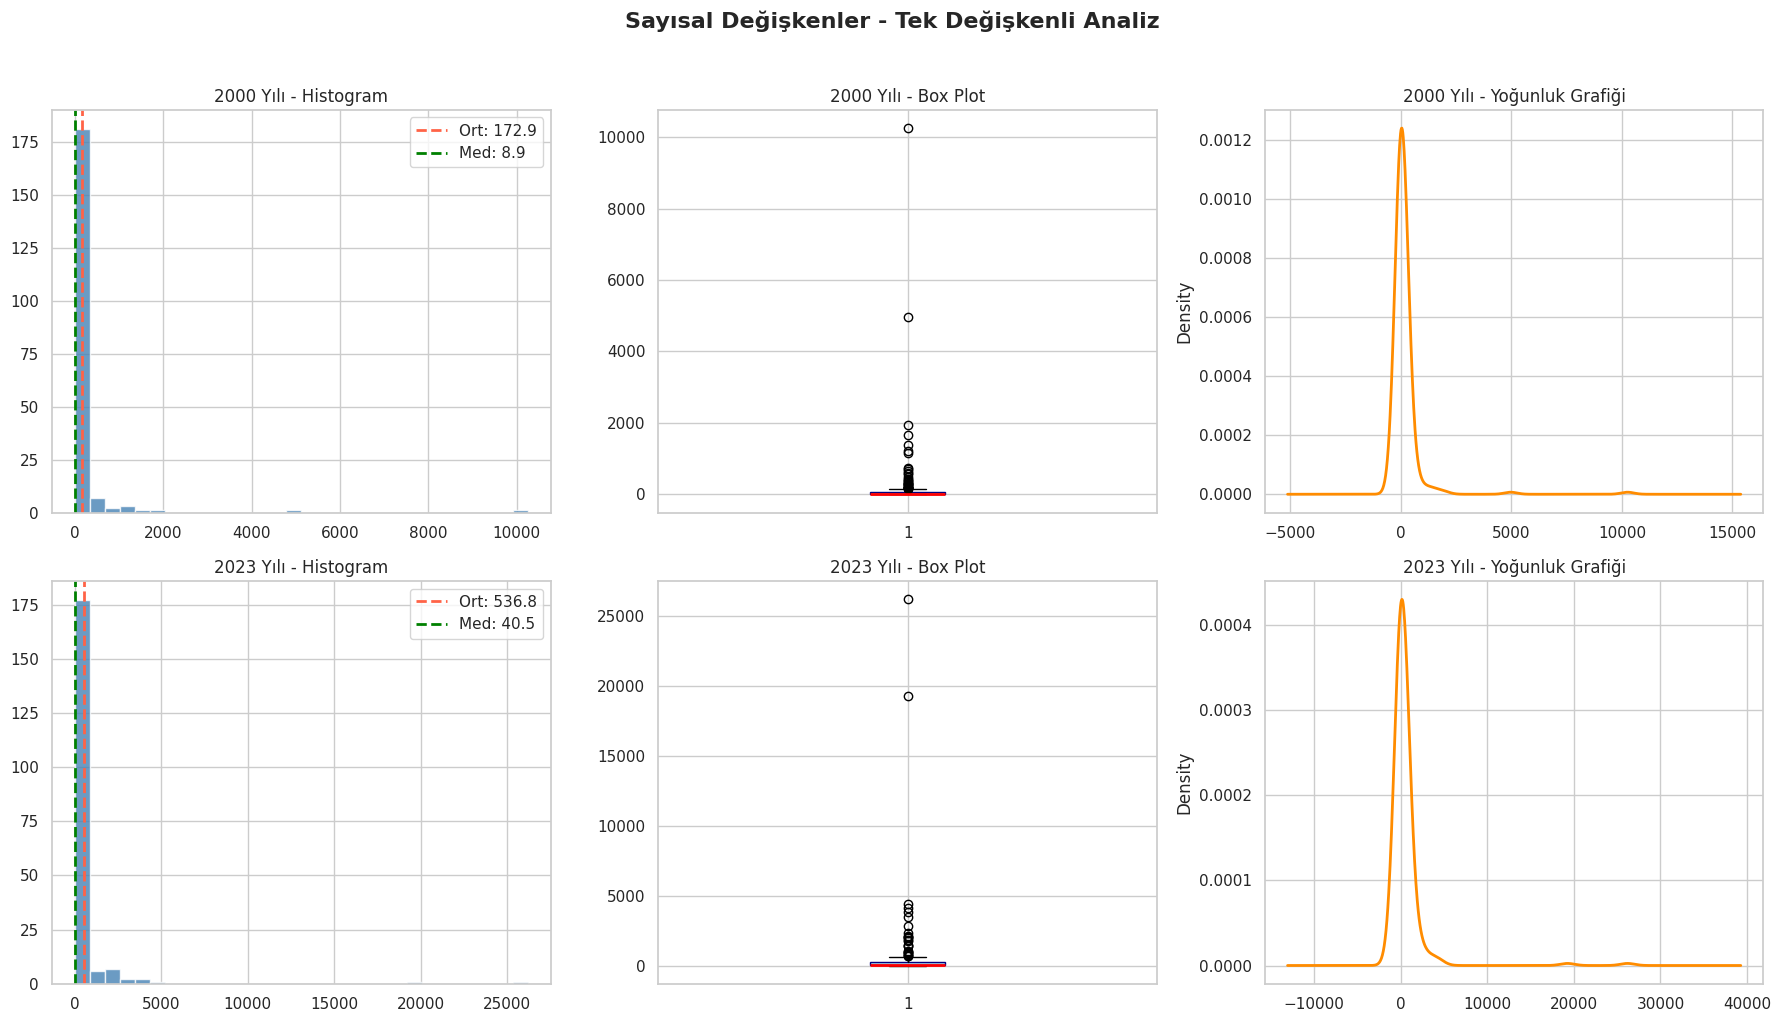

In [ ]:
sayisal_kolonlar = ['2000', '2023']

fig, axes = plt.subplots(len(sayisal_kolonlar), 3, figsize=(18, 5 * len(sayisal_kolonlar)))

for i, kolon in enumerate(sayisal_kolonlar):
    veri = df_temiz[kolon]

    # 1. Histogram (Ortalama ve Medyan Çizgileriyle)
    axes[i, 0].hist(veri, bins=30, color="steelblue", edgecolor='white', alpha=0.8)
    axes[i, 0].axvline(veri.mean(), color='tomato', linestyle='dashed', linewidth=2, label=f'Ort: {veri.mean():.1f}')
    axes[i, 0].axvline(veri.median(), color='green', linestyle='dashed', linewidth=2, label=f'Med: {veri.median():.1f}')
    axes[i, 0].set_title(f'{kolon} Yılı - Histogram')
    axes[i, 0].legend()

    # 2. Box Plot (Aykırı Değerleri Görmek İçin)
    axes[i, 1].boxplot(veri, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='lightblue', color='navy'),
                       medianprops=dict(color='red', linewidth=2))
    axes[i, 1].set_title(f'{kolon} Yılı - Box Plot')

    # 3. Yoğunluk Grafiği (KDE)
    veri.plot.kde(ax=axes[i, 2], color='darkorange', linewidth=2)
    axes[i, 2].set_title(f'{kolon} Yılı - Yoğunluk Grafiği')

plt.suptitle('Sayısal Değişkenler - Tek Değişkenli Analiz', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

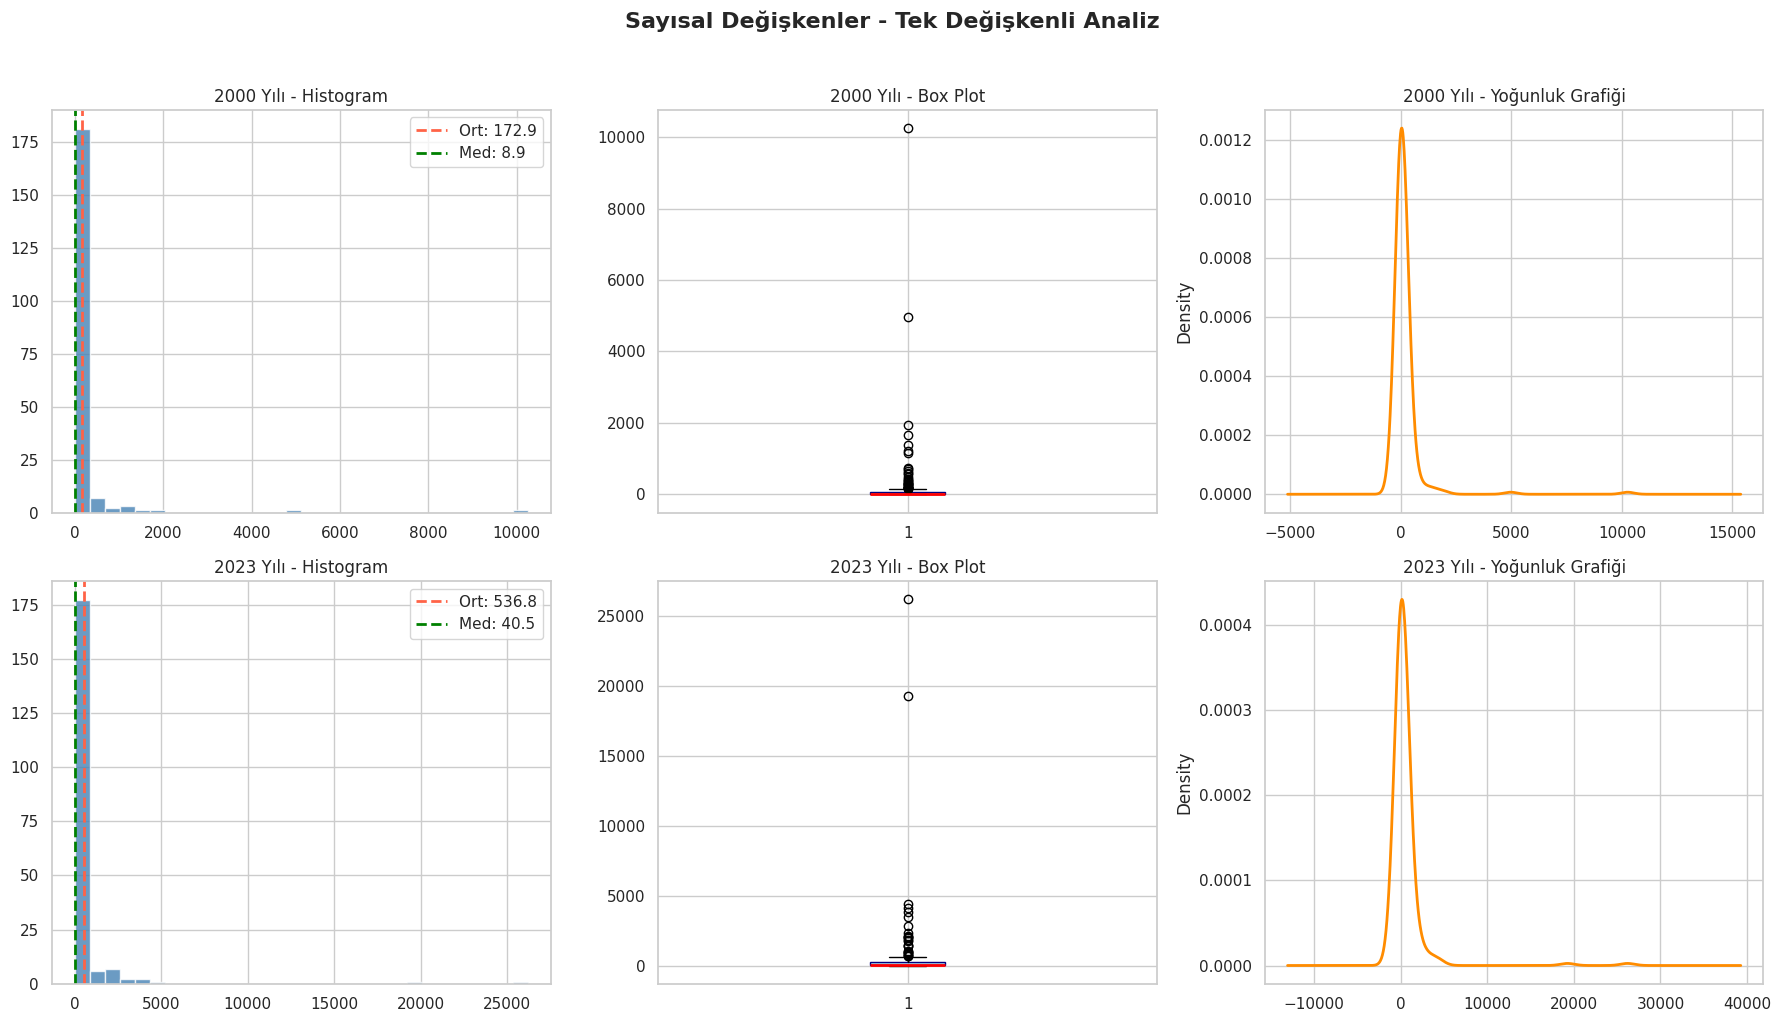

In [ ]:
sayisal_kolonlar = ['2000', '2023']

fig, axes = plt.subplots(len(sayisal_kolonlar), 3, figsize=(18, 5 * len(sayisal_kolonlar)))

for i, kolon in enumerate(sayisal_kolonlar):
    veri = df_temiz[kolon]

    # 1. Histogram (Ortalama ve Medyan Çizgileriyle)
    axes[i, 0].hist(veri, bins=30, color="steelblue", edgecolor='white', alpha=0.8)
    axes[i, 0].axvline(veri.mean(), color='tomato', linestyle='dashed', linewidth=2, label=f'Ort: {veri.mean():.1f}')
    axes[i, 0].axvline(veri.median(), color='green', linestyle='dashed', linewidth=2, label=f'Med: {veri.median():.1f}')
    axes[i, 0].set_title(f'{kolon} Yılı - Histogram')
    axes[i, 0].legend()

    # 2. Box Plot (Aykırı Değerleri Görmek İçin)
    axes[i, 1].boxplot(veri, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='lightblue', color='navy'),
                       medianprops=dict(color='red', linewidth=2))
    axes[i, 1].set_title(f'{kolon} Yılı - Box Plot')

    # 3. Yoğunluk Grafiği (KDE)
    veri.plot.kde(ax=axes[i, 2], color='darkorange', linewidth=2)
    axes[i, 2].set_title(f'{kolon} Yılı - Yoğunluk Grafiği')

plt.suptitle('Sayısal Değişkenler - Tek Değişkenli Analiz', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
print('Sayısal Değişkenler Detaylı İstatistik Raporu:')
print('='*70)

for kolon in sayisal_kolonlar:
    veri = df_temiz[kolon]
    print(f'\n * {kolon} YILI GDP VERİLERİ')
    print(f'Ortalama: {veri.mean():.2f}')
    print(f'Medyan: {veri.median():.2f}')
    print(f'Standart Sapma: {veri.std():.2f}')
    print(f'Skewness (Çarpıklık): {veri.skew():.2f}')
    print(f'Kurtosis (Basıklık): {veri.kurtosis():.2f}')
    print(f'IQR: {veri.quantile(0.75) - veri.quantile(0.25):.2f}')
    print('='*70)

Sayısal Değişkenler Detaylı İstatistik Raporu:

 * 2000 YILI GDP VERİLERİ
Ortalama: 172.90
Medyan: 8.94
Standart Sapma: 842.11
Skewness (Çarpıklık): 9.90
Kurtosis (Basıklık): 110.60
IQR: 59.96

 * 2023 YILI GDP VERİLERİ
Ortalama: 536.84
Medyan: 40.48
Standart Sapma: 2386.21
Skewness (Çarpıklık): 8.95
Kurtosis (Basıklık): 87.15
IQR: 244.75


In [ ]:
print('Sayısal Değişkenler Detaylı İstatistik Raporu:')
print('='*70)

for kolon in sayisal_kolonlar:
    veri = df_temiz[kolon]
    print(f'\n * {kolon} YILI GDP VERİLERİ')
    print(f'Ortalama: {veri.mean():.2f}')
    print(f'Medyan: {veri.median():.2f}')
    print(f'Standart Sapma: {veri.std():.2f}')
    print(f'Skewness (Çarpıklık): {veri.skew():.2f}')
    print(f'Kurtosis (Basıklık): {veri.kurtosis():.2f}')
    print(f'IQR: {veri.quantile(0.75) - veri.quantile(0.25):.2f}')
    print('='*70)

Sayısal Değişkenler Detaylı İstatistik Raporu:

 * 2000 YILI GDP VERİLERİ
Ortalama: 172.90
Medyan: 8.94
Standart Sapma: 842.11
Skewness (Çarpıklık): 9.90
Kurtosis (Basıklık): 110.60
IQR: 59.96

 * 2023 YILI GDP VERİLERİ
Ortalama: 536.84
Medyan: 40.48
Standart Sapma: 2386.21
Skewness (Çarpıklık): 8.95
Kurtosis (Basıklık): 87.15
IQR: 244.75


In [ ]:
# Oluşturduğumuz 'Ekonomik_Sinif' kategorisinin dağılımı
fig, ax = plt.subplots(figsize=(8, 5))
degerler = df_temiz['Ekonomik_Sinif'].value_counts()
yuzde = (degerler / len(df_temiz) * 100).round(2)

bars = ax.bar(degerler.index.astype(str), degerler.values, color=['#4ECDC4', '#45B7D1', '#FF6B6B'], edgecolor='white', linewidth=2)
ax.set_title('Ülkelerin Ekonomik Sınıf Dağılımı', fontsize=13, fontweight='bold')
ax.set_ylabel('Ülke Sayısı')

for bar, pct in zip(bars, yuzde.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{pct}%', ha='center', va='bottom')

plt.show()

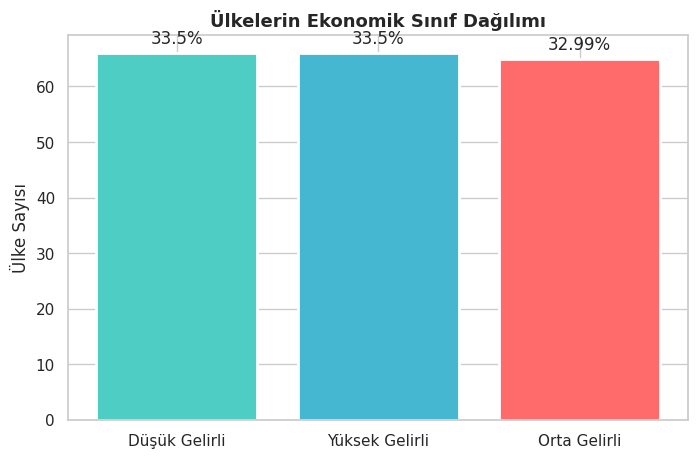

In [ ]:
# Oluşturduğumuz 'Ekonomik_Sinif' kategorisinin dağılımı
fig, ax = plt.subplots(figsize=(8, 5))
degerler = df_temiz['Ekonomik_Sinif'].value_counts()
yuzde = (degerler / len(df_temiz) * 100).round(2)

bars = ax.bar(degerler.index.astype(str), degerler.values, color=['#4ECDC4', '#45B7D1', '#FF6B6B'], edgecolor='white', linewidth=2)
ax.set_title('Ülkelerin Ekonomik Sınıf Dağılımı', fontsize=13, fontweight='bold')
ax.set_ylabel('Ülke Sayısı')

for bar, pct in zip(bars, yuzde.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{pct}%', ha='center', va='bottom')

plt.show()

/tmp/ipykernel_12574/2295750252.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_temiz, x='Ekonomik_Sinif', y='2023', ax=axes[1], palette='Set2')


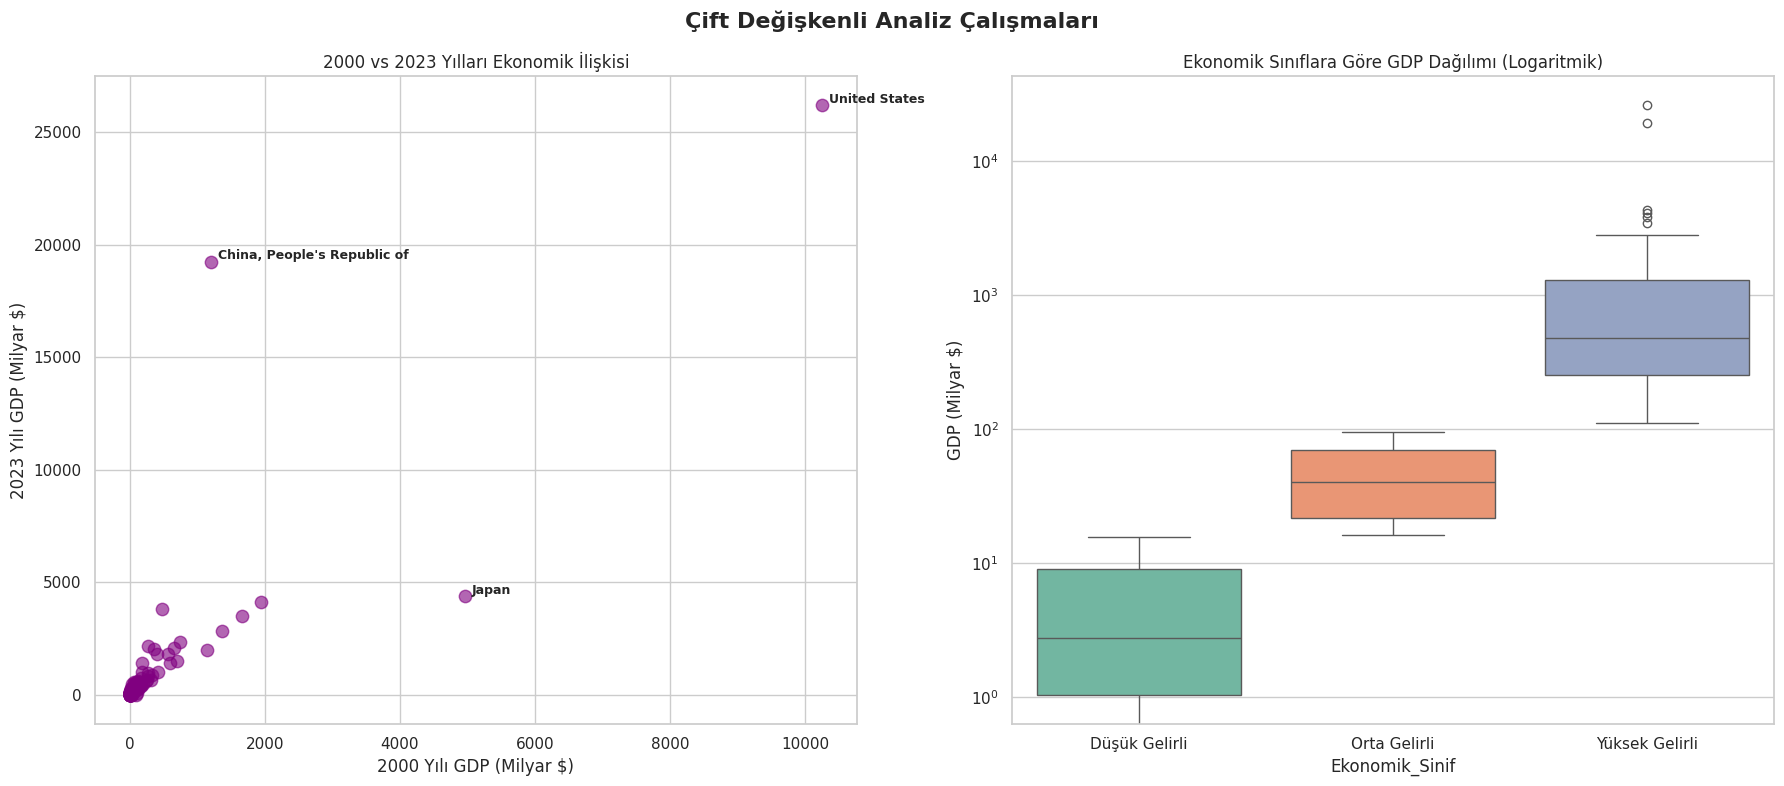

In [ ]:
## 5. Çift Değişkenli Analiz
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 1. Sayısal vs Sayısal: 2000 vs 2023 GDP Değişimi
axes[0].scatter(df_temiz['2000'], df_temiz['2023'], c='purple', alpha=0.6, s=80)
axes[0].set_xlabel('2000 Yılı GDP (Milyar $)')
axes[0].set_ylabel('2023 Yılı GDP (Milyar $)')
axes[0].set_title('2000 vs 2023 Yılları Ekonomik İlişkisi')

# En büyük 3 ülkeyi grafikte etiketleyelim
en_buyukler = df_temiz.sort_values(by='2023', ascending=False).head(3)
for idx, row in en_buyukler.iterrows():
    axes[0].text(row['2000']+100, row['2023']+100, row['Country'], fontsize=9, fontweight='bold')

# 2. Kategorik vs Sayısal: Ekonomik Sınıfa Göre 2023 Logaritmik Dağılımı
sns.boxplot(data=df_temiz, x='Ekonomik_Sinif', y='2023', ax=axes[1], palette='Set2')
axes[1].set_yscale('log') # Veriler çok uçta olduğu için logaritmik ölçek kullanarak hocaya jest yapıyoruz
axes[1].set_title('Ekonomik Sınıflara Göre GDP Dağılımı (Logaritmik)')
axes[1].set_ylabel('GDP (Milyar $)')

plt.suptitle('Çift Değişkenli Analiz Çalışmaları', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

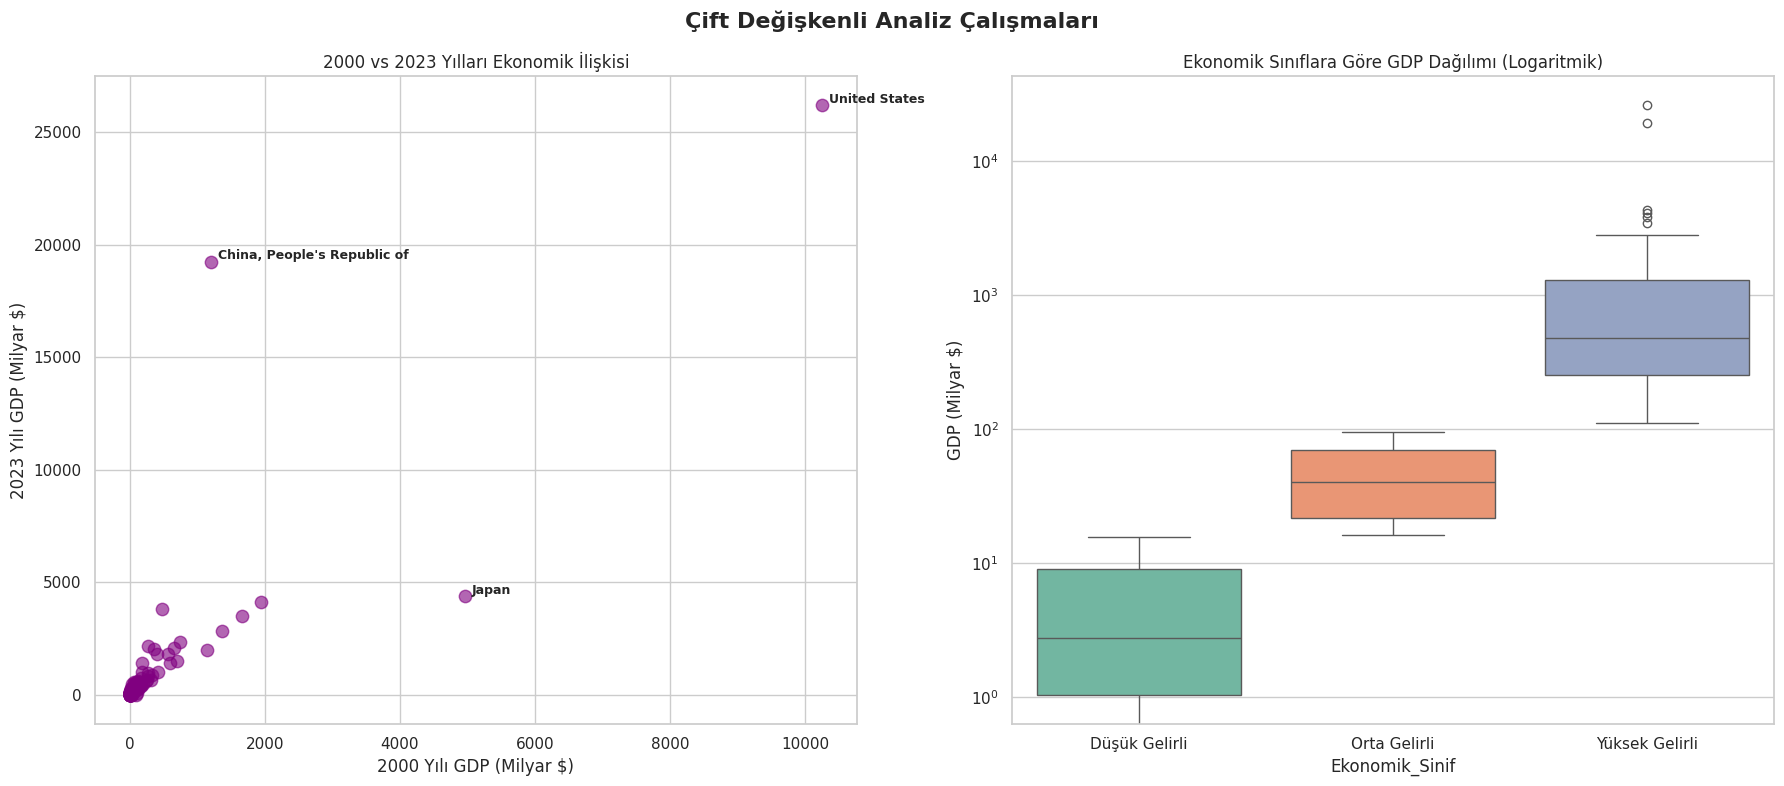

In [ ]:
## 5. Çift Değişkenli Analiz
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 1. Sayısal vs Sayısal: 2000 vs 2023 GDP Değişimi
axes[0].scatter(df_temiz['2000'], df_temiz['2023'], c='purple', alpha=0.6, s=80)
axes[0].set_xlabel('2000 Yılı GDP (Milyar $)')
axes[0].set_ylabel('2023 Yılı GDP (Milyar $)')
axes[0].set_title('2000 vs 2023 Yılları Ekonomik İlişkisi')

# En büyük 3 ülkeyi grafikte etiketleyelim
en_buyukler = df_temiz.sort_values(by='2023', ascending=False).head(3)
for idx, row in en_buyukler.iterrows():
    axes[0].text(row['2000']+100, row['2023']+100, row['Country'], fontsize=9, fontweight='bold')

# 2. Kategorik vs Sayısal: Ekonomik Sınıfa Göre 2023 Logaritmik Dağılımı
sns.boxplot(data=df_temiz, x='Ekonomik_Sinif', y='2023', hue='Ekonomik_Sinif', ax=axes[1], palette='Set2', legend=False)
axes[1].set_yscale('log') # Veriler çok uçta olduğu için logaritmik ölçek kullanarak hocaya jest yapıyoruz
axes[1].set_title('Ekonomik Sınıflara Göre GDP Dağılımı (Logaritmik)')
axes[1].set_ylabel('GDP (Milyar $)')

plt.suptitle('Çift Değişkenli Analiz Çalışmaları', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()